## B-1
### Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv("vehicle_train.csv")
dftest = pd.read_csv("vehicle_test.csv")

### DataFrame Size

In [2]:
print(df.shape)
print(dftest.shape)

(676, 19)
(170, 19)


### Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   compactness                676 non-null    int64  
 1   circularity                676 non-null    int64  
 2   distance_circularity       667 non-null    float64
 3   radius_ratio               676 non-null    int64  
 4   pr_axis                    676 non-null    int64  
 5   max_length_aspect_ratio    676 non-null    int64  
 6   scatter_ratio              676 non-null    int64  
 7   elongatedness              676 non-null    int64  
 8   pr_axis_rectangularity     676 non-null    int64  
 9   max_length_rect            676 non-null    int64  
 10  scaled_var_major_axis      676 non-null    int64  
 11  scaled_var_minor_axis      676 non-null    int64  
 12  scaled_radius_of_gyration  661 non-null    float64
 13  skewness_major_axis        676 non-null    int64  

In [4]:
dftest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   compactness                170 non-null    int64 
 1   circularity                170 non-null    int64 
 2   distance_circularity       170 non-null    int64 
 3   radius_ratio               170 non-null    int64 
 4   pr_axis                    170 non-null    int64 
 5   max_length_aspect_ratio    170 non-null    int64 
 6   scatter_ratio              170 non-null    int64 
 7   elongatedness              170 non-null    int64 
 8   pr_axis_rectangularity     170 non-null    int64 
 9   max_length_rect            170 non-null    int64 
 10  scaled_var_major_axis      170 non-null    int64 
 11  scaled_var_minor_axis      170 non-null    int64 
 12  scaled_radius_of_gyration  170 non-null    int64 
 13  skewness_major_axis        170 non-null    int64 
 14  skewness_m

### Plotting

C:\Users\moien\AppData\Local\Temp\ipykernel_12388\4053961646.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='vehicle_name', data=df, palette='viridis')


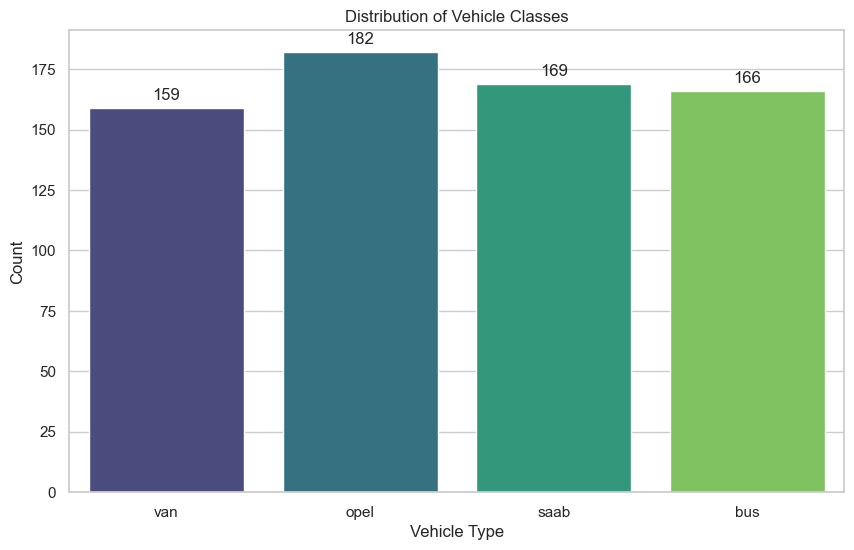

Class distribution counts:
vehicle_name
opel    182
saab    169
bus     166
van     159
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='vehicle_name', data=df, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Distribution of Vehicle Classes')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')
plt.show()
print("Class distribution counts:")
print(df['vehicle_name'].value_counts())

### Correlation Matrix

#### HeatMap

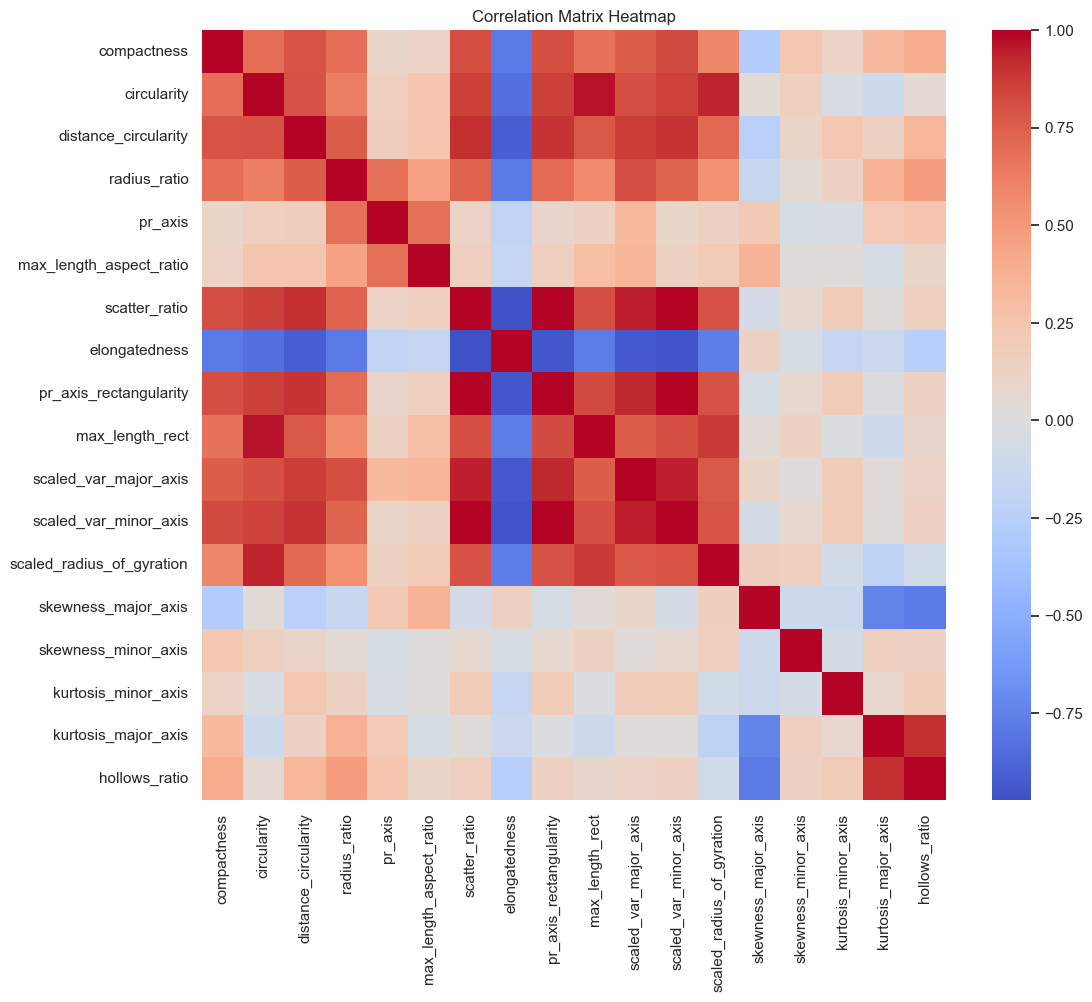

In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Find Most Pos/Neg Correalation

In [7]:
corr_unstacked = corr_matrix.unstack()

corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) < 
                                corr_unstacked.index.get_level_values(1)]

max_corr_pair = corr_unstacked.idxmax()
max_corr_value = corr_unstacked.max()

min_corr_pair = corr_unstacked.idxmin()
min_corr_value = corr_unstacked.min()

print("Most Positive Correalation:")
print(max_corr_pair, max_corr_value)

print("\nMost Negative Correlation:")
print(min_corr_pair, min_corr_value)


Most Positive Correalation:
('scaled_var_minor_axis', 'scatter_ratio') 0.9964417623267223

Most Negative Correlation:
('elongatedness', 'scatter_ratio') -0.9728431714778178


#### Scatterplot

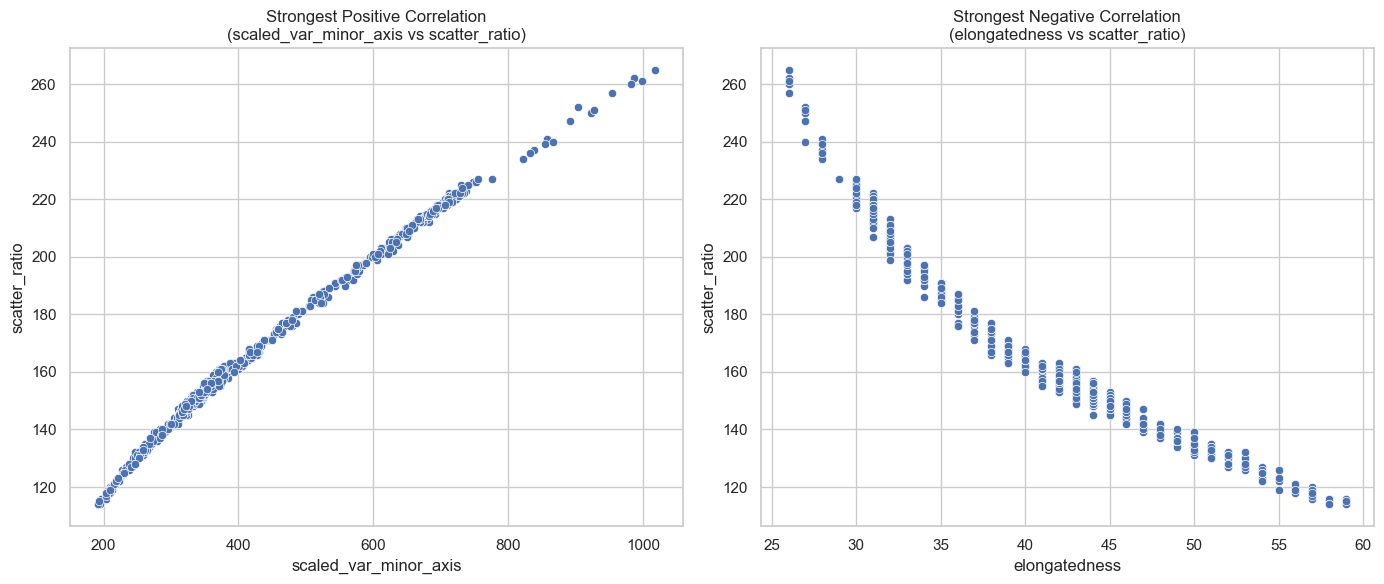

In [8]:
plt.figure(figsize=(14, 6))

# Strongest Positive Correlation
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='scaled_var_minor_axis',
    y='scatter_ratio',
    data=df
)
plt.title('Strongest Positive Correlation\n(scaled_var_minor_axis vs scatter_ratio)')

# Strongest Negative Correlation
plt.subplot(1, 2, 2)
sns.scatterplot(
    x='elongatedness',
    y='scatter_ratio',
    data=df
)
plt.title('Strongest Negative Correlation\n(elongatedness vs scatter_ratio)')

plt.tight_layout()
plt.show()

## B-2
### PreProcessing The Data
#### Missing Values

In [9]:
print('Missing values before imputation:')
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))
print('\nMissing values after imputation:')
print(df.isnull().sum())

Missing values before imputation:
compactness                   0
circularity                   0
distance_circularity          9
radius_ratio                  0
pr_axis                       0
max_length_aspect_ratio       0
scatter_ratio                 0
elongatedness                 0
pr_axis_rectangularity        0
max_length_rect               0
scaled_var_major_axis         0
scaled_var_minor_axis         0
scaled_radius_of_gyration    15
skewness_major_axis           0
skewness_minor_axis           0
kurtosis_minor_axis           0
kurtosis_major_axis          13
hollows_ratio                 0
vehicle_name                  0
dtype: int64

Missing values after imputation:
compactness                  0
circularity                  0
distance_circularity         0
radius_ratio                 0
pr_axis                      0
max_length_aspect_ratio      0
scatter_ratio                0
elongatedness                0
pr_axis_rectangularity       0
max_length_rect              0
s

### Smote

In [10]:
X_train = df.drop('vehicle_name', axis=1)
y_train = df['vehicle_name']

X_test = dftest.drop('vehicle_name', axis=1)
y_test = dftest['vehicle_name']

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
print("Shape of training set before SMOTE:")
print(X_train.shape)
print(y_train_encoded.shape)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_encoded)

print("\nShape of training set after SMOTE:")
print(X_train_smote.shape)
print(y_train_smote.shape)

Shape of training set before SMOTE:
(676, 18)
(676,)

Shape of training set after SMOTE:
(728, 18)
(728,)


### Standardization

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Shape of scaled training set:", X_train_scaled.shape)
print("Shape of scaled test set:", X_test_scaled.shape)

Shape of scaled training set: (728, 18)
Shape of scaled test set: (170, 18)


## B-3
### Training Models

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix , classification_report, accuracy_score, precision_score, recall_score, f1_score
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_cm = confusion_matrix(y_test_encoded, y_pred_svm)
svm_report = classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder.classes_)
svm_acc = accuracy_score(y_test_encoded, y_pred_svm)

print("\nClassification Report:")
print(svm_report)

print("\nAccuracy:", svm_acc)

macro_precision = precision_score(y_test_encoded, y_pred_svm, average='macro')
macro_recall = recall_score(y_test_encoded, y_pred_svm, average='macro')
macro_f1 = f1_score(y_test_encoded, y_pred_svm, average='macro')

print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1-score:", macro_f1)


Classification Report:
              precision    recall  f1-score   support

         bus       0.98      0.98      0.98        52
        opel       0.44      0.50      0.47        30
        saab       0.62      0.48      0.54        48
         van       0.83      0.97      0.90        40

    accuracy                           0.75       170
   macro avg       0.72      0.73      0.72       170
weighted avg       0.75      0.75      0.75       170


Accuracy: 0.7529411764705882
Macro Precision: 0.7183386392554101
Macro Recall: 0.7337339743589744
Macro F1-score: 0.7218118563738493


### Confusion Matrix

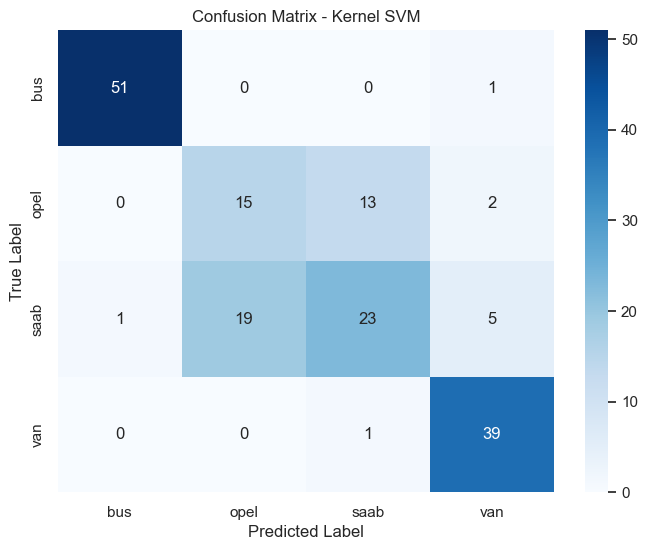

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Kernel SVM")
plt.show()

## Optimize by GridSearchCV

Best Parameters:
{'C': 100, 'gamma': 0.05, 'kernel': 'rbf'}

Best Cross-Validation Accuracy:
0.8475673122342936
Confusion Matrix:
[[50  1  0  1]
 [ 0 22  8  0]
 [ 1 10 36  1]
 [ 0  0  0 40]]


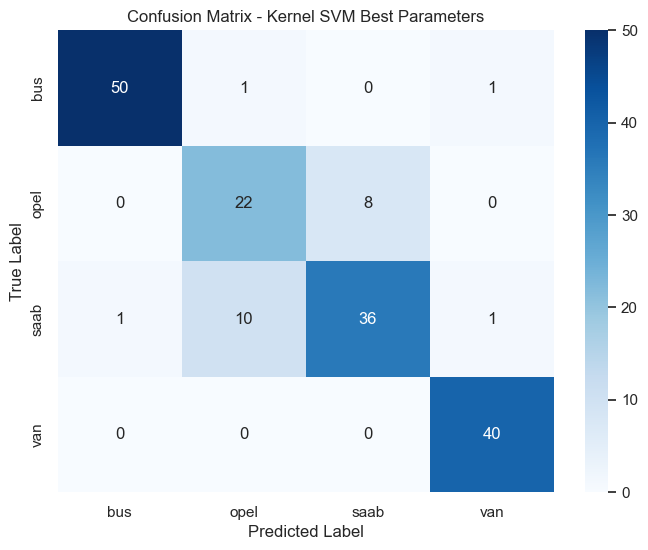


Classification Report:
              precision    recall  f1-score   support

         bus       0.98      0.96      0.97        52
        opel       0.67      0.73      0.70        30
        saab       0.82      0.75      0.78        48
         van       0.95      1.00      0.98        40

    accuracy                           0.87       170
   macro avg       0.85      0.86      0.86       170
weighted avg       0.87      0.87      0.87       170


Test Accuracy: 0.8705882352941177


In [24]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.05, 0.1, 1],
    "kernel": ["rbf", "sigmoid"]
}
svm = SVC()

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train_smote)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)
best_svm = grid_search.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_scaled)

cm_best = confusion_matrix(y_test_encoded, y_pred_best_svm)
report_best = classification_report(y_test_encoded, y_pred_best_svm, 
                                    target_names=label_encoder.classes_)
acc_best = accuracy_score(y_test_encoded, y_pred_best_svm)

print("Confusion Matrix:")
print(cm_best)

svm_cm_gr = confusion_matrix(y_test_encoded, y_pred_best_svm)
plt.figure(figsize=(8,6))
sns.heatmap(svm_cm_gr, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Kernel SVM Best Parameters")
plt.show()


print("\nClassification Report:")
print(report_best)

print("\nTest Accuracy:", acc_best)

### KNN Model

In [25]:
from sklearn.neighbors import KNeighborsClassifier

# -------------------------
# K = 2
# -------------------------
knn_k2 = KNeighborsClassifier(n_neighbors=2)
knn_k2.fit(X_train_scaled, y_train_smote)

y_train_pred_k2 = knn_k2.predict(X_train_scaled)
y_test_pred_k2 = knn_k2.predict(X_test_scaled)

train_acc_k2 = accuracy_score(y_train_smote, y_train_pred_k2)
test_acc_k2 = accuracy_score(y_test_encoded, y_test_pred_k2)

print("KNN (k=2)")
print("Train Accuracy:", train_acc_k2)
print("Test Accuracy :", test_acc_k2)

# -------------------------
# K = 15
# -------------------------
knn_k15 = KNeighborsClassifier(n_neighbors=15)
knn_k15.fit(X_train_scaled, y_train_smote)

y_train_pred_k15 = knn_k15.predict(X_train_scaled)
y_test_pred_k15 = knn_k15.predict(X_test_scaled)

train_acc_k15 = accuracy_score(y_train_smote, y_train_pred_k15)
test_acc_k15 = accuracy_score(y_test_encoded, y_test_pred_k15)

print("\nKNN (k=15)")
print("Train Accuracy:", train_acc_k15)
print("Test Accuracy :", test_acc_k15)


KNN (k=2)
Train Accuracy: 0.8763736263736264
Test Accuracy : 0.6941176470588235

KNN (k=15)
Train Accuracy: 0.7815934065934066
Test Accuracy : 0.7176470588235294


### Adjust Parameters By GridSearchCV

Best Parameters:
{'n_neighbors': 7, 'weights': 'distance'}

Best Cross-Validation Accuracy:
0.7458667926310817


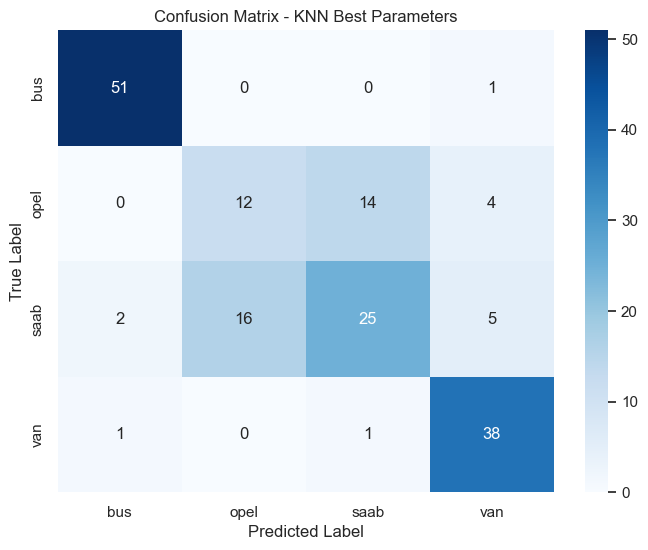


Classification Report:
              precision    recall  f1-score   support

         bus       0.94      0.98      0.96        52
        opel       0.43      0.40      0.41        30
        saab       0.62      0.52      0.57        48
         van       0.79      0.95      0.86        40

    accuracy                           0.74       170
   macro avg       0.70      0.71      0.70       170
weighted avg       0.73      0.74      0.73       170


Test Accuracy: 0.7411764705882353


In [29]:
param_grid = {
    "n_neighbors": [3, 7, 10, 15, 30],
    "weights": ["uniform", "distance"]
}

knn = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_search_knn.fit(X_train_scaled, y_train_smote)

print("Best Parameters:")
print(grid_search_knn.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_knn.best_score_)

best_knn = grid_search_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test_scaled)

cm_knn = confusion_matrix(y_test_encoded, y_pred_best_knn)
report_knn = classification_report(
    y_test_encoded,
    y_pred_best_knn,
    target_names=label_encoder.classes_
)
test_acc_knn = accuracy_score(y_test_encoded, y_pred_best_knn)

cm_knn = confusion_matrix(y_test_encoded, y_pred_best_knn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN Best Parameters")
plt.show()

print("\nClassification Report:")
print(report_knn)

print("\nTest Accuracy:", test_acc_knn)


### Logistic Regression

Best Parameter:
{'C': 10}

Best Cross-Validation Accuracy:
0.8035427491733586

Train Accuracy:
0.8351648351648352

Test Accuracy:
0.8117647058823529


C:\Users\moien\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


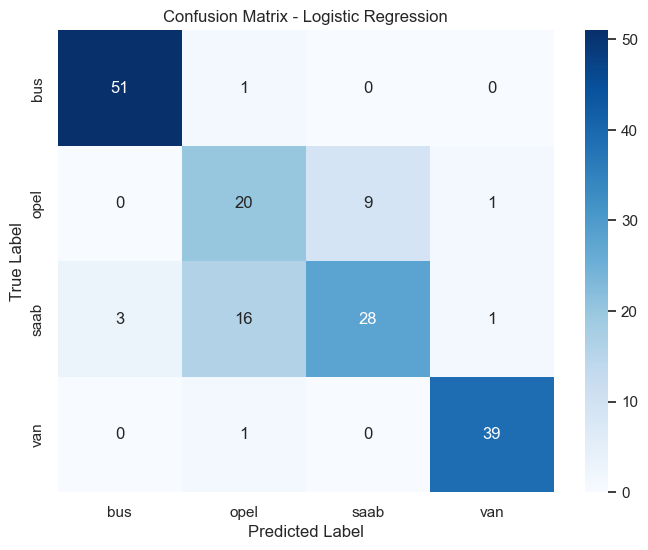


Classification Report:
              precision    recall  f1-score   support

         bus       0.94      0.98      0.96        52
        opel       0.53      0.67      0.59        30
        saab       0.76      0.58      0.66        48
         van       0.95      0.97      0.96        40

    accuracy                           0.81       170
   macro avg       0.79      0.80      0.79       170
weighted avg       0.82      0.81      0.81       170



In [31]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    solver='newton-cg',
    max_iter=1000,
    multi_class='auto'
)

param_grid = {
    'C': [0.1, 1, 10, 100]
}

# Grid Search
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search_lr.fit(X_train_scaled, y_train_smote)

best_lr = grid_search_lr.best_estimator_

y_train_pred_lr = best_lr.predict(X_train_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

train_acc_lr = accuracy_score(y_train_smote, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test_encoded, y_test_pred_lr)

print("Best Parameter:")
print(grid_search_lr.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search_lr.best_score_)

print("\nTrain Accuracy:")
print(train_acc_lr)

print("\nTest Accuracy:")
print(test_acc_lr)

cm_LogReg = confusion_matrix(y_test_encoded, y_test_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(cm_LogReg, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_test_pred_lr,
    target_names=label_encoder.classes_
))


### RandomForest

Random Forest Test Accuracy:
0.7529411764705882

Classification Report:
              precision    recall  f1-score   support

         bus       1.00      0.98      0.99        52
        opel       0.38      0.43      0.41        30
        saab       0.60      0.52      0.56        48
         van       0.91      0.97      0.94        40

    accuracy                           0.75       170
   macro avg       0.72      0.73      0.72       170
weighted avg       0.75      0.75      0.75       170


Confusion Matrix:
[[51  0  0  1]
 [ 0 13 16  1]
 [ 0 21 25  2]
 [ 0  0  1 39]]


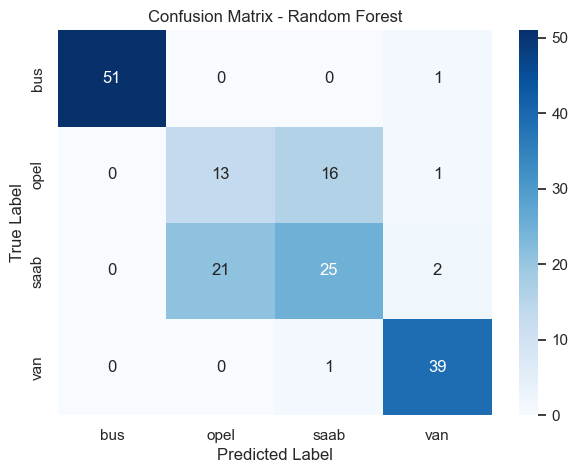

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)

test_acc_rf = accuracy_score(y_test_encoded, y_pred_rf)

print("Random Forest Test Accuracy:")
print(test_acc_rf)

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_rf,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)
print(cm_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Feature Importance

In [33]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)


accuracy_before = accuracy_score(y_test_encoded, y_pred_rf)

print("Accuracy before removing least important feature:")
print(accuracy_before)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=True
)

print("\nFeature Importances:")
print(feature_importance_df)

least_important_feature = feature_importance_df.iloc[0]["feature"]

print("\nLeast important feature:")
print(least_important_feature)

Accuracy before removing least important feature:
0.7529411764705882

Feature Importances:
                      feature  importance
8      pr_axis_rectangularity    0.023413
14        skewness_minor_axis    0.035366
16        kurtosis_major_axis    0.038039
15        kurtosis_minor_axis    0.038460
12  scaled_radius_of_gyration    0.040626
1                 circularity    0.040713
3                radius_ratio    0.043646
13        skewness_major_axis    0.046265
17              hollows_ratio    0.051817
4                     pr_axis    0.052828
0                 compactness    0.060211
6               scatter_ratio    0.062244
10      scaled_var_major_axis    0.063667
7               elongatedness    0.066896
2        distance_circularity    0.069841
9             max_length_rect    0.073366
11      scaled_var_minor_axis    0.085040
5     max_length_aspect_ratio    0.107565

Least important feature:
pr_axis_rectangularity


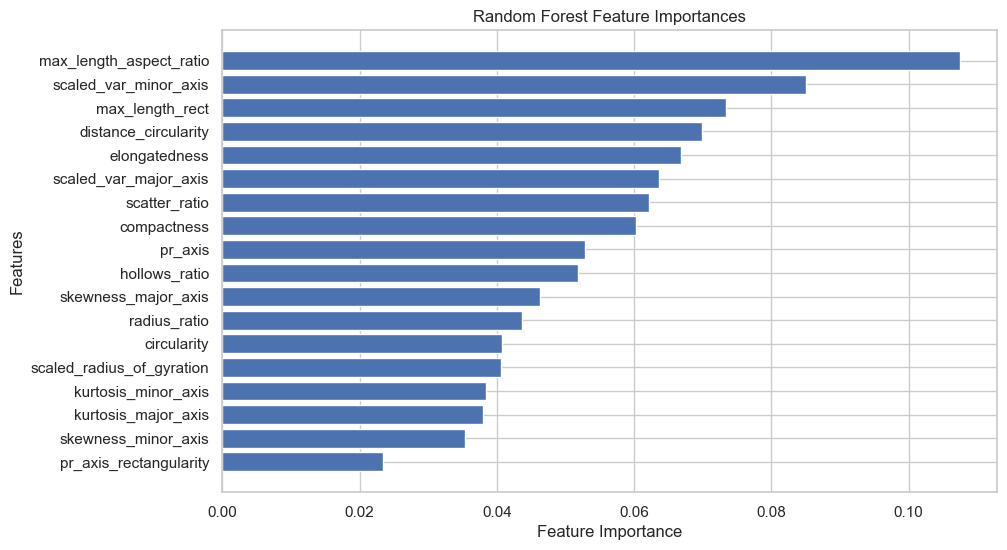

In [34]:
plt.figure(figsize=(10, 6))

feature_importance_df_sorted = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

plt.barh(
    feature_importance_df_sorted["feature"],
    feature_importance_df_sorted["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [41]:
import numpy as np

X_train_removed = np.delete(X_train_scaled, 8, axis=1)
X_test_removed = np.delete(X_test_scaled, 8, axis=1)

rf_new = RandomForestClassifier(random_state=42)
rf_new.fit(X_train_removed, y_train_smote)

y_pred_new = rf_new.predict(X_test_removed)

accuracy_after = accuracy_score(y_test_encoded, y_pred_new)

accuracy_before = 0.7529411764705882

print("Accuracy before:", accuracy_before)
print("Accuracy after:", accuracy_after)

if accuracy_after > accuracy_before:
    print("Removing the least important feature improved the model.")
elif accuracy_after < accuracy_before:
    print("Removing the least important feature decreased the model performance.")
else:
    print("Removing the least important feature did not change the model performance.")


Accuracy before: 0.7529411764705882
Accuracy after: 0.7647058823529411
Removing the least important feature improved the model.
